In [68]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [69]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 모델링
from xgboost import XGBRegressor, plot_tree
from sklearn.preprocessing import StandardScaler

# 다중공선성 검사
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 모델 평가
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [70]:
# 사용할 데이터셋 불러오기
df = pd.read_csv("/content/drive/MyDrive/폭염 대비 제주도 여름철 전력 수요 예측/최종 데이터/final_data.csv")

In [71]:
# Linear Regression에서 VIF 기반으로 power_24h, power_168h 제거한 결과 반영
numerical_columns = [
    'is_weekend',             # int64
    'tropical_night',         # int64
    'hour_sin',               # float64
    'hour_cos',               # float64
    'resident_pop',           # float64
    'working_pop',            # float64
    'visitor_pop',            # float64
    'total_visitors',         # float64
    'renewable_energy_mwh',   # float64
    'TA_mean',                # float64
    'HM_mean',                 # float64
    'HM_max',                 # float64
    'CDD',                    # float64
    'power_1h',               # float64
    # 'power_24h',               # float64
    'power_48h',              # float64
    # 'power_168h'              # float64
]

앞서 Linear Regression에서 VIF 기반으로 다중공선성이 높은 power_24h, power_168h를 제거하였으므로, 동일한 변수 구성으로 모델링을 진행한다.<br>
XGBoost는 트리 기반 모델이므로 표준화를 진행하지 않는 게 대부분이지만 앞서 진행한 선형 회귀에 맞게 진행했다.

### 모델링

In [72]:
# 시계열 기반 Train/Test 분할
# 2025년 7~8월 = 62일 × 24시간 = 1488행
test_n = 62 * 24

train_df = df.iloc[:-test_n].copy()  # 2020~2024
test_df = df.iloc[-test_n:].copy()   # 2025

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

train_df: (7440, 18)
test_df: (1488, 18)


In [73]:
target_col = "power_demand_MWh"

X_train = train_df[numerical_columns].copy()
y_train = train_df[target_col].copy()

X_test = test_df[numerical_columns].copy()
y_test = test_df[target_col].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7440, 15)
X_test: (1488, 15)
y_train: (7440,)
y_test: (1488,)


In [74]:
# 수치형 독립 변수 표준화
# 표준화
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [75]:
X_train[numerical_columns].head()

,is_weekend,tropical_night,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,CDD,power_1h,power_48h
0,-0.634598,-0.838628,2.363580e-17,1.414214,-1.013592,-0.346718,-0.901793,-0.832176,1.239268,-2.932870,-0.088540,0.198094,-0.98445,-1.452854,-1.672295
1,-0.634598,-0.838628,3.660254e-01,1.366025,-1.013592,-0.346718,-0.901793,-0.832176,1.054353,-2.964056,0.098158,0.464780,-0.98445,-1.753115,-1.898219
2,-0.634598,-0.838628,7.071068e-01,1.224745,-1.013592,-0.346718,-0.901793,-0.832176,1.042232,-3.047220,0.067041,0.464780,-0.98445,-1.945460,-2.033541
3,-0.634598,-0.838628,1.000000e+00,1.000000,-1.013592,-0.346718,-0.901793,-0.832176,0.963587,-3.078406,0.098158,0.731467,-0.98445,-2.089643,-2.109596
4,-0.634598,-0.838628,1.224745e+00,0.707107,-1.013592,-0.346718,-0.901793,-0.832176,0.793470,-3.057615,0.315971,0.864811,-0.98445,-2.156444,-2.134895


In [76]:
y_train

,power_demand_MWh
0,537.796
1,509.852
2,488.905
3,479.200
4,480.823
...,...
7435,969.650
7436,935.302
7437,880.648
7438,825.065


In [77]:
X_train

,is_weekend,tropical_night,hour_sin,hour_cos,resident_pop,working_pop,visitor_pop,total_visitors,renewable_energy_mwh,TA_mean,HM_mean,HM_max,CDD,power_1h,power_48h
0,-0.634598,-0.838628,2.363580e-17,1.414214,-1.013592,-0.346718,-0.901793,-0.832176,1.239268,-2.932870,-0.088540,0.198094,-0.984450,-1.452854,-1.672295
1,-0.634598,-0.838628,3.660254e-01,1.366025,-1.013592,-0.346718,-0.901793,-0.832176,1.054353,-2.964056,0.098158,0.464780,-0.984450,-1.753115,-1.898219
2,-0.634598,-0.838628,7.071068e-01,1.224745,-1.013592,-0.346718,-0.901793,-0.832176,1.042232,-3.047220,0.067041,0.464780,-0.984450,-1.945460,-2.033541
3,-0.634598,-0.838628,1.000000e+00,1.000000,-1.013592,-0.346718,-0.901793,-0.832176,0.963587,-3.078406,0.098158,0.731467,-0.984450,-2.089643,-2.109596
4,-0.634598,-0.838628,1.224745e+00,0.707107,-1.013592,-0.346718,-0.901793,-0.832176,0.793470,-3.057615,0.315971,0.864811,-0.984450,-2.156444,-2.134895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7435,1.575800,-0.838628,-1.366025e+00,0.366025,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,0.216950,-1.737701,-1.935400,0.016859,1.225831,1.853661
7436,1.575800,-0.838628,-1.224745e+00,0.707107,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.063727,-1.488771,-2.068743,-0.380719,1.219436,1.627806
7437,1.575800,-0.838628,-1.000000e+00,1.000000,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.302822,-1.488771,-1.802057,-0.719398,0.983011,1.233320
7438,1.575800,-0.838628,-7.071068e-01,1.224745,-1.077131,-0.817982,-1.294003,0.317006,-0.743496,-0.593895,-1.551004,-1.935400,-0.984450,0.606815,0.797439


In [78]:
# 다중공선성 검사 (VIF)
vif = pd.DataFrame()
vif['features'] = X_train.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i)
                    for i in range(X_train.shape[1])]

vif.sort_values(by="VIF Factor", ascending=False).round(1)

,features,VIF Factor
13,power_1h,10.1
12,CDD,7.7
9,TA_mean,7.4
14,power_48h,6.8
10,HM_mean,6.7
11,HM_max,5.6
2,hour_sin,3.8
5,working_pop,2.3
4,resident_pop,2.3
3,hour_cos,2.1


In [79]:
# 인덱스 재정렬
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

### XGBoost

In [80]:
# XGBoost 회귀 모델 학습
# 하이퍼파라미터 설정 근거:
#   - n_estimators=300: 충분한 트리 수로 잔차를 보정하되 과적합 방지
#   - learning_rate=0.05: 낮은 학습률로 안정적 수렴 (n_estimators와 반비례 관계)
#   - max_depth=3: 얕은 트리로 개별 트리의 복잡도를 제한하여 과적합 방지
#   - min_child_weight=3: 리프 노드 최소 샘플 수를 높여 노이즈에 민감한 분할 방지
#   - subsample=0.8, colsample_bytree=0.8: 행/열 샘플링으로 다양성 확보
#   - reg_lambda=1.0: L2 규제로 계수 크기 제한

xgb = XGBRegressor(
    objective='reg:squarederror', # 회귀 문제
    n_estimators=300,             # 트리 개수
    learning_rate=0.05,           # 학습률
    max_depth=3,                  # 트리 깊이
    min_child_weight=3,
    subsample=0.8,                # 행 샘플링
    colsample_bytree=0.8,         # 변수 샘플링
    reg_lambda=1.0,               # L2 규제
    random_state=2,
    n_jobs=-1
)

# train 데이터로 모델 학습
xgb.fit(X_train, y_train)

# test 데이터로 예측
pred_test_xgb = xgb.predict(X_test)

In [81]:
# 변수 중요도 확인
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
})

# 중요도 높은 순서대로 정렬
xgb_importance = xgb_importance.sort_values(by='importance', ascending=False)
xgb_importance

,feature,importance
13,power_1h,0.523460
14,power_48h,0.189529
9,TA_mean,0.146097
2,hour_sin,0.047365
3,hour_cos,0.044316
0,is_weekend,0.024716
8,renewable_energy_mwh,0.011849
12,CDD,0.005901
10,HM_mean,0.001394
11,HM_max,0.001267


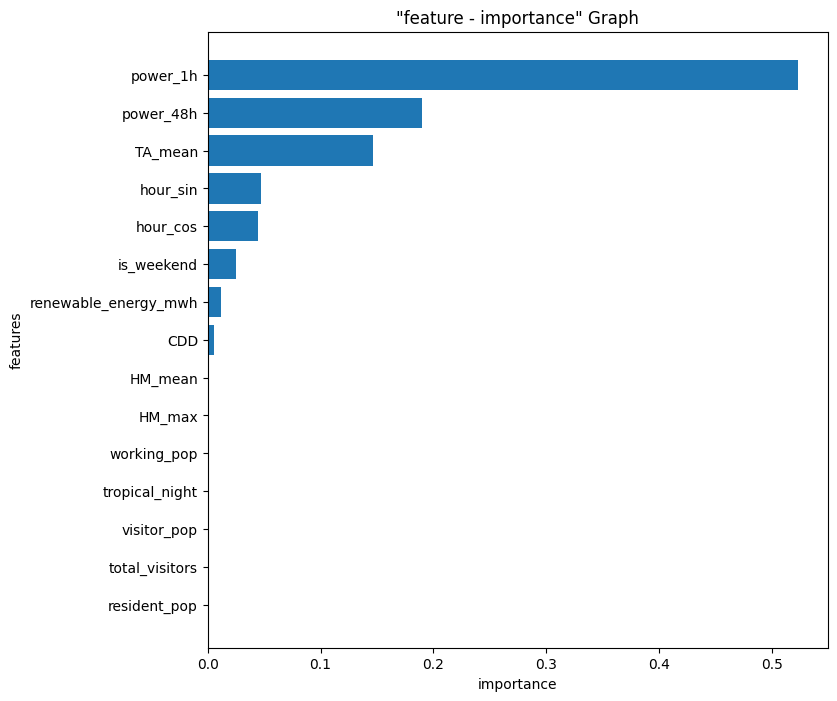

In [82]:
# 변수 중요도 시각화
plt.figure(figsize=(8, 8))

plt.barh(xgb_importance['feature'], xgb_importance['importance'])
plt.title('"feature - importance" Graph')
plt.xlabel('importance')
plt.ylabel('features')
plt.gca().invert_yaxis()
plt.show()

#### 변수 중요도 해석

- **power_1h (52.3%)**: 1시간 전 전력 수요가 가장 중요한 예측 변수 — 전력 수요의 관성(시간적 자기상관)을 반영
- **power_48h (18.9%)**: 이틀 전 같은 시간대의 수요 패턴이 두 번째로 중요
- **TA_mean (14.6%)**: 평균 기온이 세 번째 — 폭염 시 냉방 수요 증가를 직접 반영
- **hour_sin/cos (4.7%, 4.4%)**: 시간대별 전력 수요 패턴 (낮 vs 밤)
- 나머지 변수들은 중요도가 낮지만, 앙상블 모델 특성상 소수 기여도 누적됨

In [83]:
# 예측값과 실제값 비교
df_pred_xgb = pd.DataFrame({
    'actual': y_test,
    'prediction': pred_test_xgb
})

df_pred_xgb = df_pred_xgb.sort_values(by='actual').reset_index(drop=True)
df_pred_xgb.head()

,actual,prediction
0,562.533,568.862854
1,565.407,573.361267
2,576.758,573.400146
3,581.504,591.879883
4,584.632,585.449402


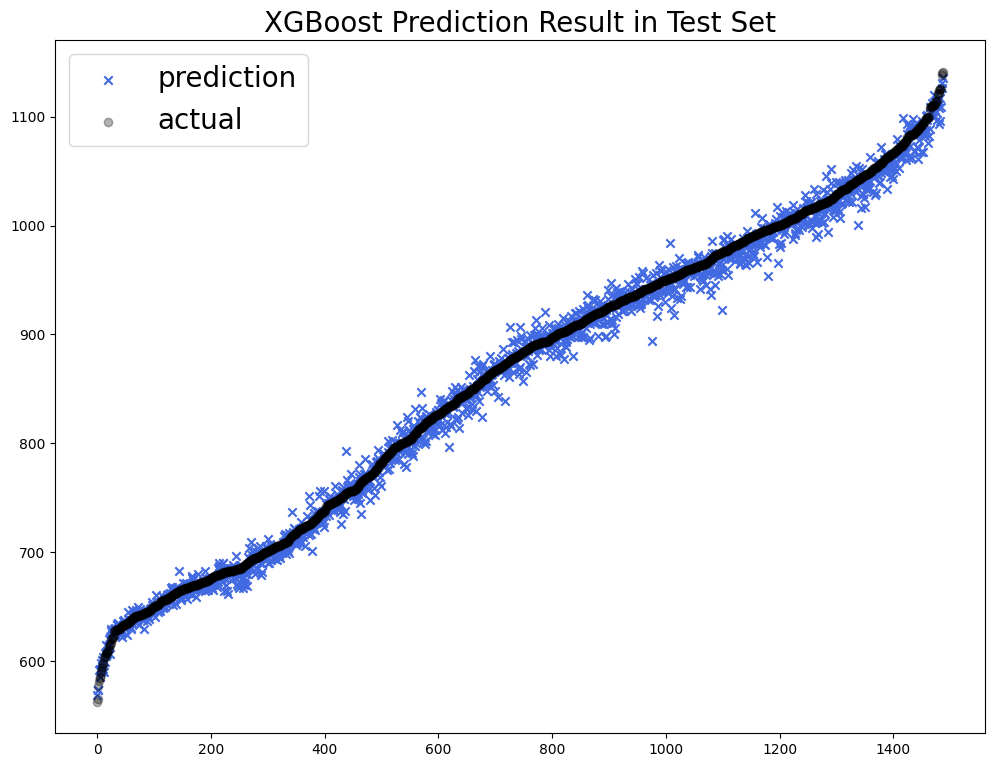

In [84]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(12, 9))

plt.scatter(df_pred_xgb.index, df_pred_xgb['prediction'], marker='x', color='royalblue')
plt.scatter(df_pred_xgb.index, df_pred_xgb['actual'], alpha=0.3, marker='o', color='black')

plt.title("XGBoost Prediction Result in Test Set", fontsize=20)
plt.legend(['prediction', 'actual'], fontsize=20)
plt.show()

In [85]:
# 모델 성능 평가
pred_train_xgb = xgb.predict(X_train)

print('R-Squared')
print("train: ", xgb.score(X_train, y_train))
print("test: ", xgb.score(X_test, y_test))

# print('\nRSS')
# print("train: ", np.sum((y_train - pred_train_xgb)**2))
# print("test: ", np.sum((y_test - pred_test_xgb)**2))

print('\nMSE')
print("train: ", mean_squared_error(y_train, pred_train_xgb))
print("test: ", mean_squared_error(y_test, pred_test_xgb))

print('\nRMSE')
print("train: ", sqrt(mean_squared_error(y_train, pred_train_xgb)))
print("test: ", sqrt(mean_squared_error(y_test, pred_test_xgb)))

R-Squared
train:  0.9947304410752864
test:  0.9945914127892318

MSE
train:  111.20236847407044
test:  109.03311776222047

RMSE
train:  10.54525336225121
test:  10.441892441613277


<Figure size 2500x1200 with 0 Axes>

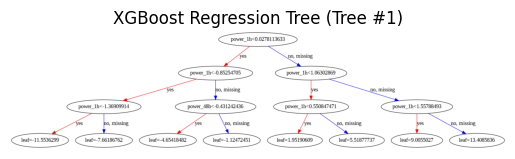

In [86]:
# XGBoost 트리 구조 시각화 (첫 번째 트리)
plt.figure(figsize=(25, 12))
plot_tree(xgb, tree_idx=0)
plt.title("XGBoost Regression Tree (Tree #1)")
plt.show()

$$power\_demand\_MWh = Base\_Value + f_1(x) + f_2(x) + \cdots + f_{300}(x)$$


- $Base\_Value$: 전체 전력 수요의 평균적 기준값
- $f_1(x) \cdots f_{300}(x)$: 각 트리가 앞선 예측의 잔차를 순차적으로 보정하는 함수
- 각 트리의 기여는 learning_rate(0.05)에 의해 축소되어 합산됨

### 하이퍼파라미터 후보 비교
아래 코드는 최종 test 데이터를 바로 튜닝에 사용하지 않기 위해, train 데이터 안에서 사용하지 않기 위해, train 데이터 안에서 마지막 1년치를 validation 데이터로 분리해 여러 하이퍼파라미터 조합을 비교

train -> validation으로 후보 비교하고, 마지막에 test로 최종 확인하는 흐름


In [87]:
# 하이퍼파라미터 후보 비교용 validation set 생성
# train_df는 2020~2024년, test_df는 2025년으로 분리되어 있음
# 여기서는 train 내부의 마지막 1년치(2024년 7~8월 = 62일 * 24시간)를 validation으로 사용

from IPython.display import display

valid_n = 62 * 24

X_sub_train = X_train.iloc[:-valid_n].copy()
y_sub_train = y_train.iloc[:-valid_n].copy()

X_valid = X_train.iloc[-valid_n:].copy()
y_valid = y_train.iloc[-valid_n:].copy()

print("X_sub_train:", X_sub_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)


X_sub_train: (5952, 15)
X_valid: (1488, 15)
X_test: (1488, 15)


#### 비교할 하이퍼파라미터 조합

- `n_estimators`: 트리 개수
- `learning_rate`: 학습률
- `max_depth`: 트리 깊이
- `min_child_weight`: 리프 노드 분할을 보수적으로 만드는 값
- `subsample`: 행 샘플링 비율
- `colsample_bytree`: 변수 샘플링 비율
- `reg_lambda`: L2 규제 강도


In [88]:
# 여러 하이퍼파라미터 조합 실험
# 기준: validation RMSE가 낮고, train과 validation 성능 차이가 너무 크지 않은 모델을 선택

xgb_param_candidates = [
    {
        "model_name": "현재 모델",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0
    },
    {
        "model_name": "더 단순한 모델",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0
    },
    {
        "model_name": "트리 수 증가 + 학습률 감소",
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0
    },
    {
        "model_name": "조금 더 복잡한 모델",
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0
    },
    {
        "model_name": "규제 강화 모델",
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "subsample": 0.7,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0
    },
    {
        "model_name": "빠르게 학습하는 모델",
        "n_estimators": 200,
        "learning_rate": 0.08,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0
    }
]

hp_results = []

for candidate in xgb_param_candidates:
    model_name = candidate["model_name"]
    params = {k: v for k, v in candidate.items() if k != "model_name"}

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=2,
        n_jobs=-1,
        **params
    )

    model.fit(X_sub_train, y_sub_train)

    pred_sub_train = model.predict(X_sub_train)
    pred_valid = model.predict(X_valid)

    train_rmse = sqrt(mean_squared_error(y_sub_train, pred_sub_train))
    valid_rmse = sqrt(mean_squared_error(y_valid, pred_valid))

    hp_results.append({
        "model_name": model_name,
        **params,
        "train_R2": round(r2_score(y_sub_train, pred_sub_train), 4),
        "valid_R2": round(r2_score(y_valid, pred_valid), 4),
        "train_RMSE": round(train_rmse, 4),
        "valid_RMSE": round(valid_rmse, 4),
        "RMSE_gap(valid-train)": round(valid_rmse - train_rmse, 4)
    })

hp_results_df = pd.DataFrame(hp_results)
hp_results_df = hp_results_df.sort_values(by=["valid_RMSE", "RMSE_gap(valid-train)"], ascending=[True, True]).reset_index(drop=True)

display(hp_results_df)


,model_name,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,train_R2,valid_R2,train_RMSE,valid_RMSE,RMSE_gap(valid-train)
0,조금 더 복잡한 모델,300,0.05,4,3,0.8,0.8,1.0,0.9961,0.9897,8.4747,15.2909,6.8162
1,빠르게 학습하는 모델,200,0.08,3,3,0.8,0.8,1.0,0.9942,0.9887,10.3683,16.0432,5.6749
2,트리 수 증가 + 학습률 감소,500,0.03,3,3,0.8,0.8,1.0,0.9943,0.9883,10.2650,16.3013,6.0363
3,현재 모델,300,0.05,3,3,0.8,0.8,1.0,0.9942,0.9877,10.3276,16.7457,6.4182
4,규제 강화 모델,400,0.03,3,5,0.7,0.8,2.0,0.9937,0.9872,10.8361,17.0942,6.2581
5,더 단순한 모델,200,0.05,2,5,0.8,0.8,2.0,0.9895,0.9814,13.9834,20.5417,6.5583


#### Validation 기준 최적 후보로 Test 성능 확인

위 표에서 validation RMSE가 가장 낮은 후보를 선택한 뒤, 다시 전체 train 데이터(2020~2024년)로 학습하고 최종 test 데이터(2025년)에서 성능을 확인한다.  
이 셀을 실행하면 기존에 사용한 현재 모델과 validation 기준 최적 후보의 test 성능을 비교할 수 있다.


In [89]:
# validation 기준 최적 후보 선택
best_model_name = hp_results_df.loc[0, "model_name"]
best_candidate = next(item for item in xgb_param_candidates if item["model_name"] == best_model_name)
best_params = {k: v for k, v in best_candidate.items() if k != "model_name"}

print("Validation 기준 선택 모델:", best_model_name)
print("선택된 하이퍼파라미터:")
for k, v in best_params.items():
    print(f"- {k}: {v}")

# 선택된 후보를 전체 train 데이터로 재학습
xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=2,
    n_jobs=-1,
    **best_params
)

xgb_best.fit(X_train, y_train)

pred_train_xgb_best = xgb_best.predict(X_train)
pred_test_xgb_best = xgb_best.predict(X_test)

# 기존 모델(xgb)과 선택 모델(xgb_best)의 최종 test 성능 비교
pred_train_xgb_current = xgb.predict(X_train)
pred_test_xgb_current = xgb.predict(X_test)

final_compare_df = pd.DataFrame([
    {
        "model_name": "기존 현재 모델",
        "train_R2": round(r2_score(y_train, pred_train_xgb_current), 4),
        "test_R2": round(r2_score(y_test, pred_test_xgb_current), 4),
        "train_MSE": round(mean_squared_error(y_train, pred_train_xgb_current), 4),
        "test_MSE": round(mean_squared_error(y_test, pred_test_xgb_current), 4),
        "train_RMSE": round(sqrt(mean_squared_error(y_train, pred_train_xgb_current)), 4),
        "test_RMSE": round(sqrt(mean_squared_error(y_test, pred_test_xgb_current)), 4)
    },
    {
        "model_name": f"Validation 선택 모델: {best_model_name}",
        "train_R2": round(r2_score(y_train, pred_train_xgb_best), 4),
        "test_R2": round(r2_score(y_test, pred_test_xgb_best), 4),
        "train_MSE": round(mean_squared_error(y_train, pred_train_xgb_best), 4),
        "test_MSE": round(mean_squared_error(y_test, pred_test_xgb_best), 4),
        "train_RMSE": round(sqrt(mean_squared_error(y_train, pred_train_xgb_best)), 4),
        "test_RMSE": round(sqrt(mean_squared_error(y_test, pred_test_xgb_best)), 4)
    }
])

display(final_compare_df)


Validation 기준 선택 모델: 조금 더 복잡한 모델
선택된 하이퍼파라미터:
- n_estimators: 300
- learning_rate: 0.05
- max_depth: 4
- min_child_weight: 3
- subsample: 0.8
- colsample_bytree: 0.8
- reg_lambda: 1.0


,model_name,train_R2,test_R2,train_MSE,test_MSE,train_RMSE,test_RMSE
0,기존 현재 모델,0.9947,0.9946,111.2024,109.0331,10.5453,10.4419
1,Validation 선택 모델: 조금 더 복잡한 모델,0.9964,0.9945,76.8842,110.6742,8.7684,10.5202


XGBoost는 트리를 순차적으로 쌓으면서 오차를 보정하는 모델이기 때문에, 트리가 너무 깊거나 학습률이 너무 크면 과적합될 수 있다고 판단했습니다. 그래서 현재 모델은 `max_depth`를 3으로 얕게 두고, `learning_rate`를 0.05로 낮게 설정했습니다. 대신 `n_estimators`를 300으로 두어 작은 보정을 여러 번 누적하도록 했습니다. 또한 `subsample`과 `colsample_bytree`를 0.8로 설정해 일부 데이터와 변수만 사용하도록 하여 과적합을 줄이고자 했습니다. 추가로 train 데이터 안에서 validation 구간을 나누어 여러 조합을 비교했고, validation RMSE와 train-validation 성능 차이를 함께 확인해 최종 설정의 안정성을 점검했습니다.

트리 깊이를 4로 늘리면 validation 성능은 좋아졌지만, 최종 test 성능 개선으로 이어지지는 않았습니다. 그래서 모델을 더 복잡하게 만들기보다는 max_depth=3, learning_rate=0.05로 안정적으로 학습한 모델을 현재 모델로 선택했습니다.
